# Model Analysis

In [6]:
import pandas as pd
import numpy as np
import glob, os, re

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [7]:
RED = "#ef7a78"
GREEN = "#68C5B3"
THRESHOLD = 300

eval_file = "_Evals_Results_SIT_Mar-07_2350"

DATA_DIR  = "../data/SIT"
EVAL_FILE = f"../results/{eval_file}.csv"
POOR_THRESHOLD = 0.6

In [8]:
df = pd.read_csv(EVAL_FILE)
rf = df[df["Algorithm"] == "REINFORCE"].copy()

# Deduplicate: keep one row per (Model File, Training File, Test File) combo
# Multiple rounds produce identical scores – use mean per unique combo
rf_dedup = rf.groupby(["Model File", "Attention Mechanism", "Training File", "Test File"], as_index=False)["Eval_Score"].mean()

print(f"Total REINFORCE unique evaluations : {len(rf_dedup)}")
print(f"Poor performing (Eval_Score < {POOR_THRESHOLD}): {(rf_dedup['Eval_Score'] < POOR_THRESHOLD).sum()}")
rf_dedup.head(3)


Total REINFORCE unique evaluations : 0
Poor performing (Eval_Score < 0.6): 0


,Model File,Attention Mechanism,Training File,Test File,Eval_Score


## Angle 1 — Attention Mechanism
- Is there an attention mechanism whose average Eval_Score drags REINFORCE below 0.4?

Overall REINFORCE Avg Eval_Score : nan

Empty DataFrame
Columns: [Attention Mechanism, Avg_Score, Poor_Count, Total, Poor_Rate_%]
Index: []

>>> Attention mechanisms BELOW overall average (nan): []


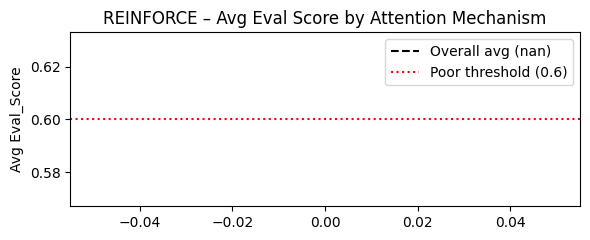

In [9]:
## Angle 1 — Attention Mechanism
# Is there an attention mechanism whose average Eval_Score drags REINFORCE below 0.4?

# Per-attention-mechanism: avg score and poor-rate
attn_stats = rf_dedup.groupby("Attention Mechanism")["Eval_Score"].agg(
    Avg_Score="mean",
    Poor_Count=lambda s: (s < POOR_THRESHOLD).sum(),
    Total="count"
).reset_index()
attn_stats["Poor_Rate_%"] = (attn_stats["Poor_Count"] / attn_stats["Total"] * 100).round(1)
attn_stats = attn_stats.sort_values("Avg_Score")

overall_avg = rf_dedup["Eval_Score"].mean()
print(f"Overall REINFORCE Avg Eval_Score : {overall_avg:.4f}")
print()
print(attn_stats.to_string(index=False))

# Flag attention mechanisms whose avg score is below the overall average
poor_attn = attn_stats[attn_stats["Avg_Score"] < overall_avg]["Attention Mechanism"].tolist()
print(f"\n>>> Attention mechanisms BELOW overall average ({overall_avg:.4f}): {poor_attn}")

# Bar chart
fig, ax = plt.subplots(figsize=(6, 2.5))
colors = [RED if m in poor_attn else GREEN for m in attn_stats["Attention Mechanism"]]
ax.bar(attn_stats["Attention Mechanism"], attn_stats["Avg_Score"], color=colors)
ax.axhline(overall_avg, color="black", linestyle="--", label=f"Overall avg ({overall_avg:.3f})")
ax.axhline(POOR_THRESHOLD, color="red", linestyle=":", label=f"Poor threshold ({POOR_THRESHOLD})")
ax.set_ylabel("Avg Eval_Score"); ax.set_title("REINFORCE – Avg Eval Score by Attention Mechanism")
ax.legend(); plt.tight_layout(); plt.show()


In [10]:
## Angle 1 — Model names with poor Eval_Score linked to each flagged attention mechanism

for attn in poor_attn:
    poor_models = rf_dedup[
        (rf_dedup["Attention Mechanism"] == attn) &
        (rf_dedup["Eval_Score"] < POOR_THRESHOLD)
    ][["Model File", "Training File", "Test File", "Eval_Score"]].sort_values("Eval_Score")
    print(f"\n{'='*60}")
    print(f"Attention: {attn}  |  {len(poor_models)} poor evaluations (score < {POOR_THRESHOLD})")
    print(f"{'='*60}")
    for _, row in poor_models.iterrows():
        print(f"  {row['Model File']}  |  train={row['Training File']}  test={row['Test File']}  score={row['Eval_Score']:.4f}")


## Angle 2 — Training File
- Does a particular training file produce models that perform poorly across all test sets?

Overall REINFORCE Avg Eval_Score : nan

Empty DataFrame
Columns: [Training File, Avg_Score, Poor_Count, Total, Poor_Rate_%]
Index: []

>>> Training files BELOW overall average (nan): []


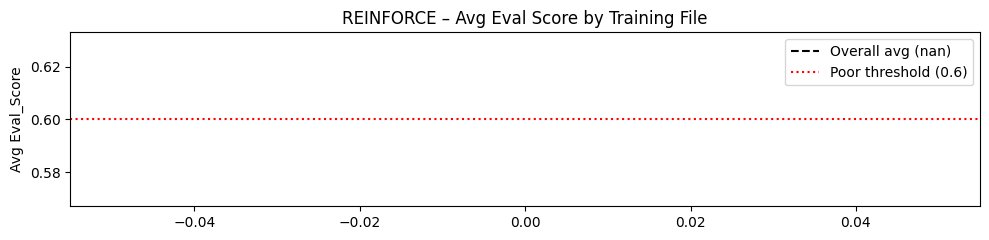

In [11]:
## Angle 2 — Training File
# Does a particular training file produce models that perform poorly across all test sets?

train_stats = rf_dedup.groupby("Training File")["Eval_Score"].agg(
    Avg_Score="mean",
    Poor_Count=lambda s: (s < POOR_THRESHOLD).sum(),
    Total="count"
).reset_index()
train_stats["Poor_Rate_%"] = (train_stats["Poor_Count"] / train_stats["Total"] * 100).round(1)
train_stats = train_stats.sort_values("Avg_Score")

train_overall_avg = rf_dedup["Eval_Score"].mean()
print(f"Overall REINFORCE Avg Eval_Score : {train_overall_avg:.4f}")
print()
print(train_stats.to_string(index=False))

# Training files whose avg score is below than overall average
poor_train = train_stats[train_stats["Avg_Score"] < train_overall_avg]["Training File"].tolist()
print(f"\n>>> Training files BELOW overall average ({train_overall_avg:.4f}): {poor_train}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 2.5))
colors = [RED if t in poor_train else GREEN for t in train_stats["Training File"]]
ax.bar(train_stats["Training File"], train_stats["Avg_Score"], color=colors)
ax.axhline(train_overall_avg, color="black", linestyle="--", label=f"Overall avg ({train_overall_avg:.3f})")
ax.axhline(POOR_THRESHOLD, color="red", linestyle=":", label=f"Poor threshold ({POOR_THRESHOLD})")
ax.set_ylabel("Avg Eval_Score"); ax.set_title("REINFORCE – Avg Eval Score by Training File")
ax.legend(); plt.tight_layout(); plt.show()


In [12]:
## Angle 2 — Model names with poor Eval_Score linked to each flagged training file

for train_file in poor_train:
    poor_models = rf_dedup[
        (rf_dedup["Training File"] == train_file) &
        (rf_dedup["Eval_Score"] < POOR_THRESHOLD)
    ][["Model File", "Attention Mechanism", "Test File", "Eval_Score"]].sort_values("Eval_Score")
    print(f"\n{'='*60}")
    print(f"Training File: {train_file}  |  {len(poor_models)} poor evaluations (score < {POOR_THRESHOLD})")
    print(f"{'='*60}")
    for _, row in poor_models.iterrows():
        print(f"  {row['Model File']}  |  attn={row['Attention Mechanism']}  test={row['Test File']}  score={row['Eval_Score']:.4f}")


## Angle 3 — Test File
- Identify Evalution files showing poor performance

Overall REINFORCE Avg Eval_Score : nan

Empty DataFrame
Columns: [Test File, Avg_Score, Poor_Count, Total, Poor_Rate_%]
Index: []

>>> Test files BELOW overall average (nan): []


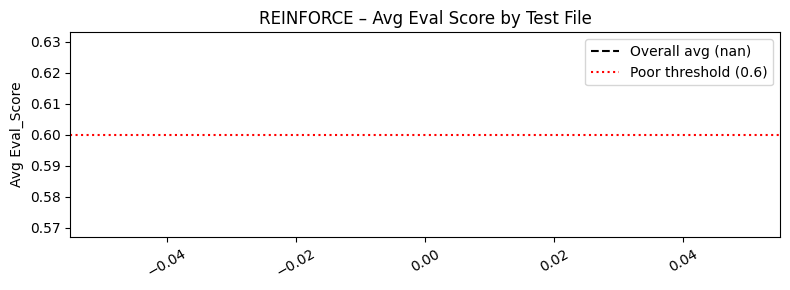

In [13]:
## Angle 3 — Test File
# Is it a specific test file that causes poor performance regardless of which model is evaluated?

test_stats = rf_dedup.groupby("Test File")["Eval_Score"].agg(
    Avg_Score="mean",
    Poor_Count=lambda s: (s < POOR_THRESHOLD).sum(),
    Total="count"
).reset_index()
test_stats["Poor_Rate_%"] = (test_stats["Poor_Count"] / test_stats["Total"] * 100).round(1)
test_stats = test_stats.sort_values("Avg_Score")

test_overall_avg = rf_dedup["Eval_Score"].mean()
print(f"Overall REINFORCE Avg Eval_Score : {test_overall_avg:.4f}")
print()
print(test_stats.to_string(index=False))

# Test files below overall average
poor_test = test_stats[test_stats["Avg_Score"] < test_overall_avg]["Test File"].tolist()
print(f"\n>>> Test files BELOW overall average ({test_overall_avg:.4f}): {poor_test}")

# Bar chart — sorted by score
fig, ax = plt.subplots(figsize=(8, 3))
colors = [RED if t in poor_test else GREEN for t in test_stats["Test File"]]
ax.bar(test_stats["Test File"], test_stats["Avg_Score"], color=colors)
ax.axhline(test_overall_avg, color="black", linestyle="--", label=f"Overall avg ({test_overall_avg:.3f})")
ax.axhline(POOR_THRESHOLD, color="red", linestyle=":", label=f"Poor threshold ({POOR_THRESHOLD})")
ax.set_ylabel("Avg Eval_Score"); ax.set_title("REINFORCE – Avg Eval Score by Test File")
ax.legend(); plt.xticks(rotation=30); plt.tight_layout(); plt.show()


In [14]:
## Angle 3 — Model names with poor Eval_Score linked to each flagged test file

for test_file in poor_test:
    poor_models = rf_dedup[
        (rf_dedup["Test File"] == test_file) &
        (rf_dedup["Eval_Score"] < POOR_THRESHOLD)
    ][["Model File", "Attention Mechanism", "Training File", "Eval_Score"]].sort_values("Eval_Score")
    print(f"\n{'='*60}")
    print(f"Test File: {test_file}  |  {len(poor_models)} poor evaluations (score < {POOR_THRESHOLD})")
    print(f"{'='*60}")
    for _, row in poor_models.iterrows():
        print(f"  {row['Model File']}  |  attn={row['Attention Mechanism']}  train={row['Training File']}  score={row['Eval_Score']:.4f}")


## TOOL WEAR Plots

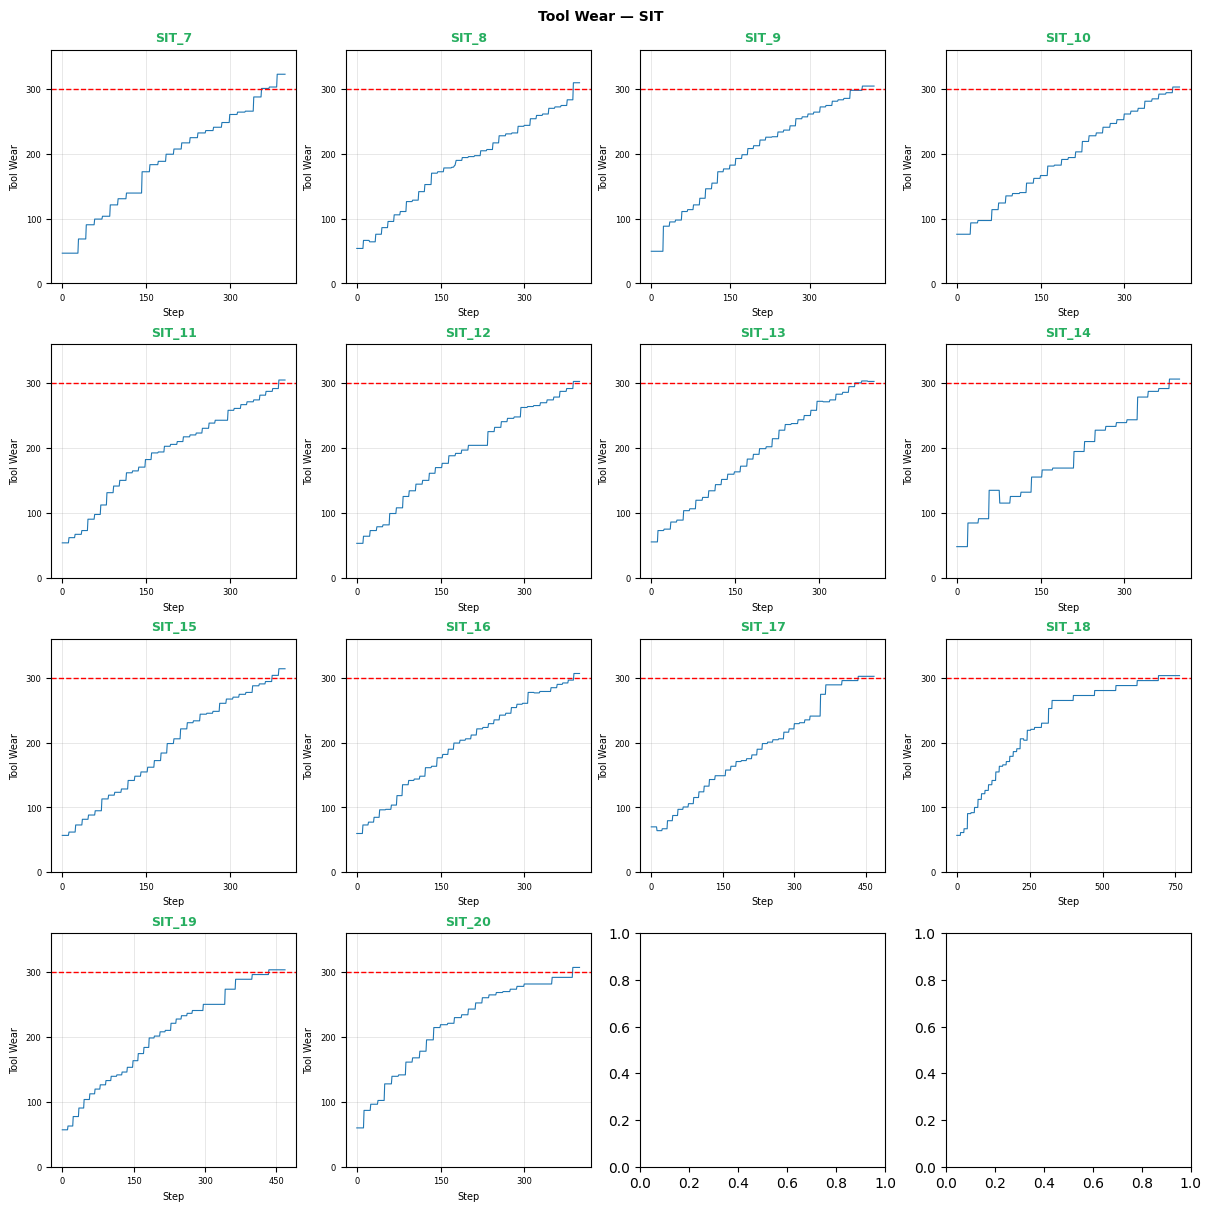

In [15]:
def plot_tool_wear(data_dir, threshold=300, ncols=4):
    """Plot tool_wear vs step for every CSV in data_dir.

    Files are sorted by the trailing numeric suffix (XXX_NN).
    Title is green when tool_wear crosses the threshold, red when it does not.
    """
    def _sort_key(fpath):
        m = re.search(r'_(\d+)(?:\.[^.]+)?$', os.path.basename(fpath))
        return int(m.group(1)) if m else float('inf')

    files = sorted(glob.glob(os.path.join(data_dir, "*.csv")), key=_sort_key)
    n     = len(files)
    nrows = -(-n // ncols)   # ceiling division

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 3, nrows * 3),
                             constrained_layout=True)
    axes = axes.flat

    for ax, fpath in zip(axes, files):
        label   = os.path.splitext(os.path.basename(fpath))[0]
        tw      = pd.read_csv(fpath)["tool_wear"]
        crossed = tw.max() >= threshold

        ax.plot(tw, color="#1f77b4", linewidth=0.8)
        ax.axhline(threshold, color="red", linestyle="--", linewidth=1.0)
        ax.set_title(label, fontsize=9,
                     color="#27ae60" if crossed else "#c0392b",
                     fontweight="bold")
        ax.set_ylim(0, threshold * 1.2)
        ax.set_xlabel("Step", fontsize=7)
        ax.set_ylabel("Tool Wear", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(4))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(4))
        ax.grid(True, color="grey", alpha=0.25, linewidth=0.5)

    for ax in list(axes)[n:]:
        ax.set_visible(False)

    fig.suptitle(f"Tool Wear — {os.path.basename(data_dir)}  ", fontsize=10, fontweight="bold")
    plt.show()


# ── calls ─────────────────────────────────────────────────────────────
plot_tool_wear(DATA_DIR, threshold=THRESHOLD, ncols=4)

## Extend non-crossing files so tool_wear crosses threshold

- Strategy: find the last stair-step period, repeat it with tool_wear incremented by one median step each cycle, until we clear THRESHOLD.

In [16]:
## Extend non-crossing files so tool_wear crosses threshold
# Strategy: find the last stair-step period, repeat it with tool_wear
# incremented by one median step each cycle, until we clear THRESHOLD.

files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))

# ── identify non-crossing files ───────────────────────────────────────
non_crossing = []
for fpath in files:
    df_raw = pd.read_csv(fpath)
    if df_raw["tool_wear"].max() < THRESHOLD:
        non_crossing.append(fpath)

print(f"Files that did NOT cross {THRESHOLD}: {[os.path.basename(f) for f in non_crossing]}")

# ── extend each file in memory ────────────────────────────────────────
extended_data = {}   # label -> (original_len, full_df)

for fpath in non_crossing:
    df_raw  = pd.read_csv(fpath).reset_index(drop=True)
    tw      = df_raw["tool_wear"]

    # median positive step size
    diffs     = tw.diff().dropna()
    step_size = diffs[diffs > 0].median()

    # length of one stair tread: rows where tool_wear equals the last value
    last_val   = tw.iloc[-1]
    tread_mask = tw == last_val
    # find the start of the last tread
    tread_start = tread_mask[::-1].idxmin()   # first False counting from end
    if not tread_mask.iloc[0]:                # guard: whole series isn't flat
        tread_start = tread_start + 1
    else:
        tread_start = 0
    tread_period = len(df_raw) - tread_start

    # build extension: repeat the tread block, raising tool_wear each repeat
    chunks   = [df_raw]
    cur_base = last_val
    while cur_base < THRESHOLD:
        cur_base += step_size
        block = df_raw.iloc[-tread_period:].copy()
        block["tool_wear"] = round(cur_base, 4)
        chunks.append(block)

    df_ext = pd.concat(chunks, ignore_index=True)
    orig_len = len(df_raw)
    extended_data[os.path.basename(fpath)] = (orig_len, df_ext)
    print(f"  {os.path.basename(fpath):12s}  original={orig_len} rows  "
          f"extended={len(df_ext)} rows  new_max={df_ext['tool_wear'].max():.2f}")

# ── plot ──────────────────────────────────────────────────────────────
n     = len(non_crossing)
ncols = min(n, 3)
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 4, nrows * 3.5),
                         constrained_layout=True)
axes_flat = np.array(axes).flat if n > 1 else [axes]

for ax, (label, (orig_len, df_ext)) in zip(axes_flat, extended_data.items()):
    tw_all = df_ext["tool_wear"]

    # original part in blue, appended part in orange
    ax.plot(range(orig_len),        tw_all[:orig_len],  color="#1f77b4", linewidth=1.0, label="Original")
    ax.plot(range(orig_len - 1, len(df_ext)), tw_all[orig_len - 1:],
            color="#ff7f0e", linewidth=1.2, linestyle="--", label="Extended")

    ax.axvline(orig_len - 1, color="grey", linestyle=":", linewidth=0.8, alpha=0.7)
    ax.axhline(THRESHOLD, color="red", linestyle="--", linewidth=1.0, label=f"Threshold {THRESHOLD}")

    ax.set_ylim(0, THRESHOLD + 30)
    ax.set_title(label, fontsize=9, color="#c0392b", fontweight="bold")
    ax.set_xlabel("Step", fontsize=7)
    ax.set_ylabel("Tool Wear", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5))
    ax.grid(True, color="grey", alpha=0.25, linewidth=0.5)
    ax.legend(fontsize=6, loc="upper left")

for ax in list(axes_flat)[n:]:
    ax.set_visible(False)

fig.suptitle("Extended tool_wear (blue=original · orange=added · red dashed=threshold)",
             fontsize=10, fontweight="bold")
plt.show()


Files that did NOT cross 300: []


ZeroDivisionError: integer division or modulo by zero

In [ ]:
## ── Save extended files ──────────────────────────────────────────────
# Set CONFIRM = True once you are happy with the extended data above,
# then run this cell to write copies into ../data/SIT_Extended/

CONFIRM = True          # <── change to True to actually write files
OUT_DIR = "../data/SIT_Extended"

if not CONFIRM:
    print("Nothing saved.  Set CONFIRM = True and re-run this cell to save copies.")
else:
    os.makedirs(OUT_DIR, exist_ok=True)
    for label, (orig_len, df_ext) in extended_data.items():
        out_path = os.path.join(OUT_DIR, label)
        df_ext.to_csv(out_path, index=False)
        print(f"  Saved -> {out_path}  ({len(df_ext)} rows)")
    print(f"\nDone. {len(extended_data)} file(s) written to '{OUT_DIR}'")


  Saved -> ../data/SIT_Extended/SIT_18.csv  (765 rows)

Done. 1 file(s) written to '../data/SIT_Extended'


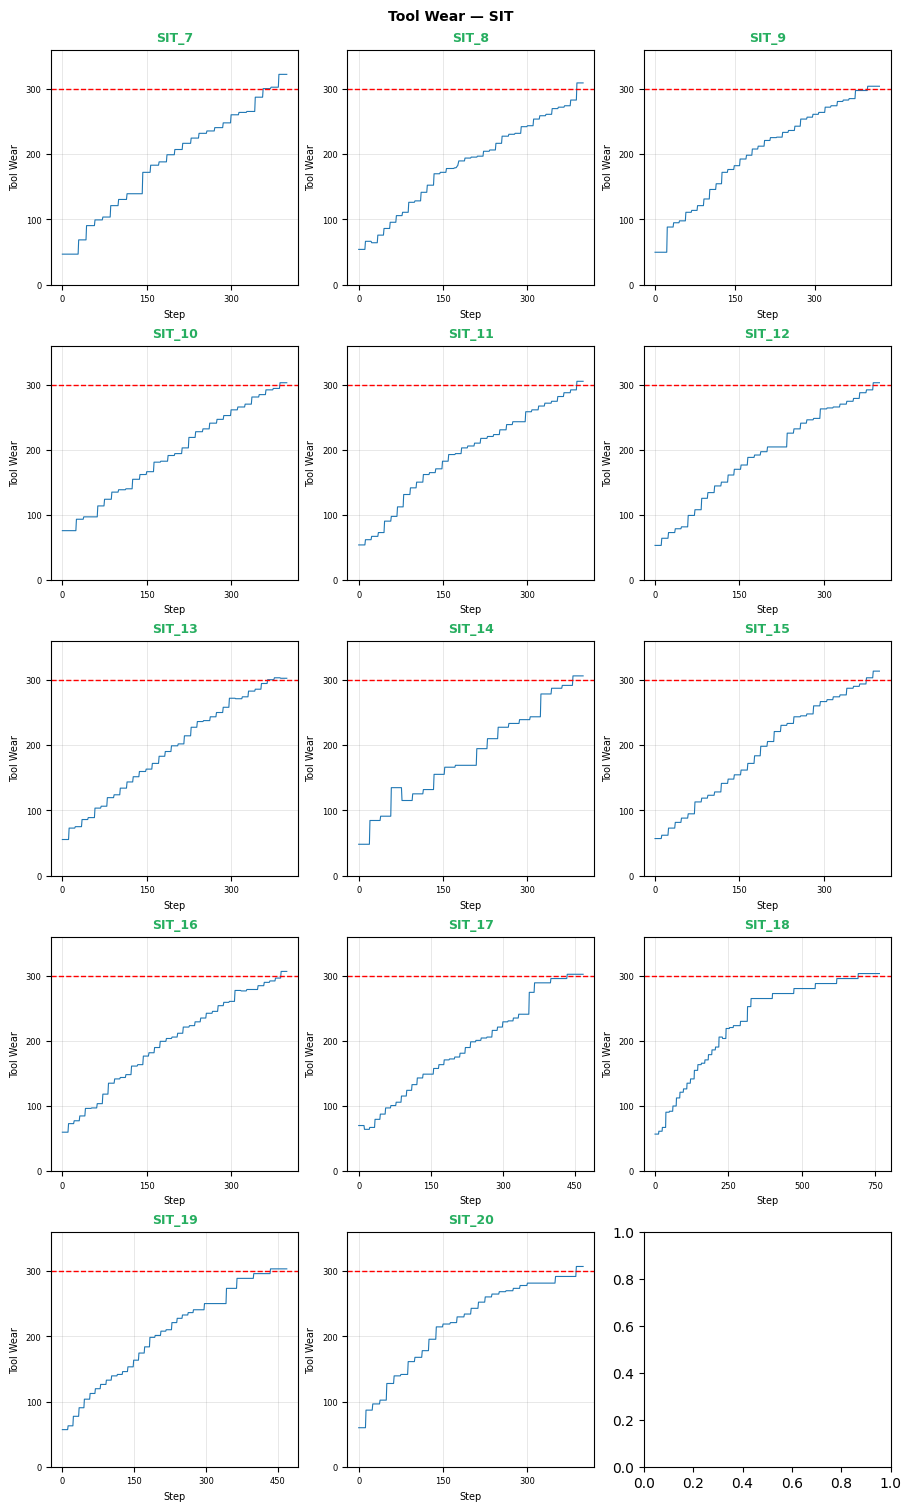

In [ ]:
plot_tool_wear(DATA_DIR, threshold=THRESHOLD, ncols=3)

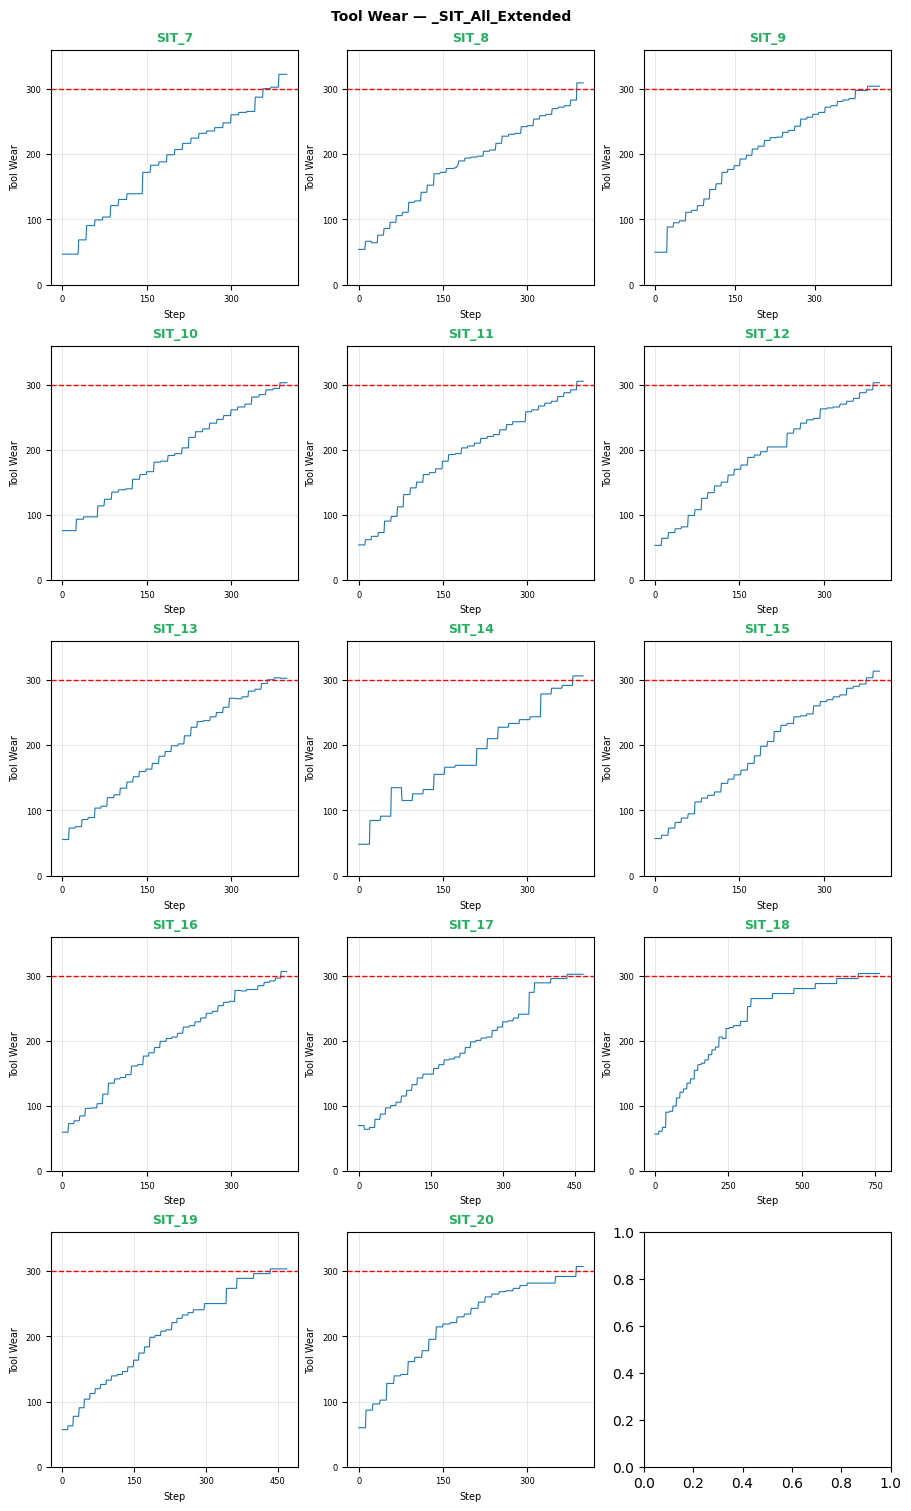

In [ ]:
fldr = '../data/_SIT_All_Extended'

plot_tool_wear(fldr, threshold=THRESHOLD, ncols=3)